In [71]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [72]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [73]:
epochs_var = 50
train_size = 1000
test_size = (train_size * 10) // 2

aug_parameter = 0.05

In [74]:
X_train.shape

(60000, 28, 28)

In [75]:
X_test.shape

(10000, 28, 28)

In [76]:
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')/255.0
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')/255.0

X_train = X_train[:train_size]
y_train = y_train[:train_size]
X_test = X_test[:test_size]
y_test = y_test[:test_size]

In [77]:
print(y_train[:10])

[5 0 4 1 9 2 1 3 1 4]


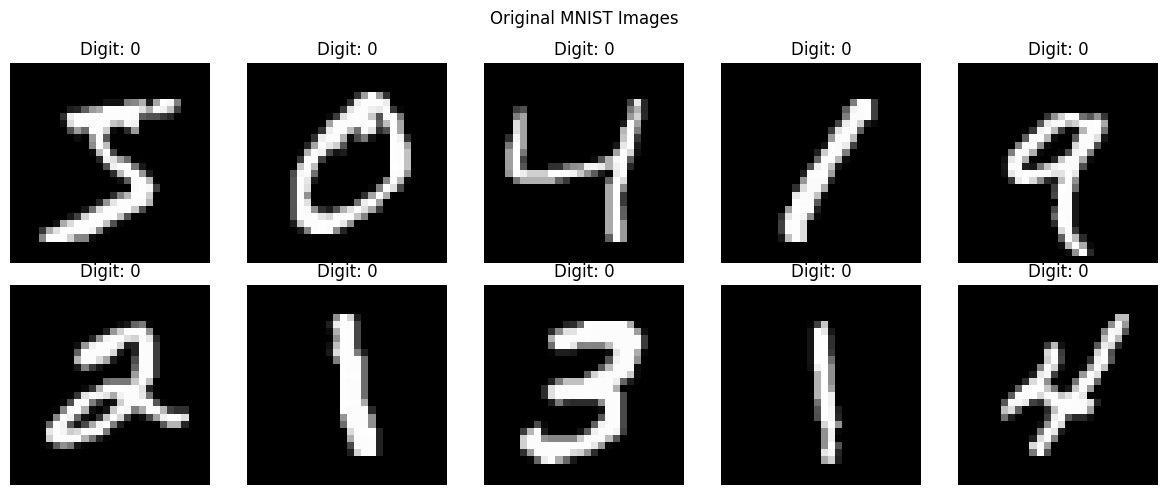

In [78]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    axes[i//5, i%5].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i//5, i%5].set_title(f'Digit: {np.argmax(y_train[i])}')
    axes[i//5, i%5].axis('off')
plt.suptitle('Original MNIST Images')
plt.tight_layout()
plt.show()

The numerical lebels should be converted to OHC vectors.

In [79]:
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)
print(y_test[0])


[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [80]:
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation = 'relu', input_shape = (28, 28, 1)))
    model.add(MaxPooling2D(2, 2)) 

    model.add(Conv2D(64, (3, 3), activation = 'relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())
    
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))


    model.compile(
        optimizer = Adam(learning_rate= 0.001 ),
        loss = 'categorical_crossentropy',
        metrics = ['accuracy']
    )

    return model
    

    

## Training Model WITHOUT Data Augmentation

In [81]:
model_without_augmetation = create_model()
hist1 = model_without_augmetation.fit(
    X_train, y_train,
    epochs = epochs_var,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)

/home/rithik/coding/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.3738 - loss: 1.9157 - val_accuracy: 0.6100 - val_loss: 1.2644
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6875 - loss: 0.9818 - val_accuracy: 0.8000 - val_loss: 0.6361
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8025 - loss: 0.6001 - val_accuracy: 0.8800 - val_loss: 0.4988
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8700 - loss: 0.4499 - val_accuracy: 0.8850 - val_loss: 0.4229
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8950 - loss: 0.3604 - val_accuracy: 0.9100 - val_loss: 0.3857
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9075 - loss: 0.2992 - val_accuracy: 0.9050 - val_loss: 0.3667
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9275 - loss: 0.2365 - val_accuracy: 0.9250 - val_loss: 0.3357
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9325 - loss: 0.2043 - val_accuracy: 0.9400 - va

In [82]:
model_without_augmetation.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [83]:
# Evaluate on test set
loss_without, acc_without = model_without_augmetation.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print("Model WITHOUT Data Augmentation")
print("=" * 50)
print(f"Test Loss: {loss_without:.4f}")
print(f"Test Accuracy: {acc_without:.4f}")
print("=" * 50)

Model WITHOUT Data Augmentation
Test Loss: 0.3950
Test Accuracy: 0.9234


## Creating Data Augmentation Pipeline

In [84]:
augmentation  = ImageDataGenerator(
    rotation_range = 20,
    width_shift_range = aug_parameter,
    height_shift_range = aug_parameter,
    zoom_range = aug_parameter,
    fill_mode = 'nearest'
)

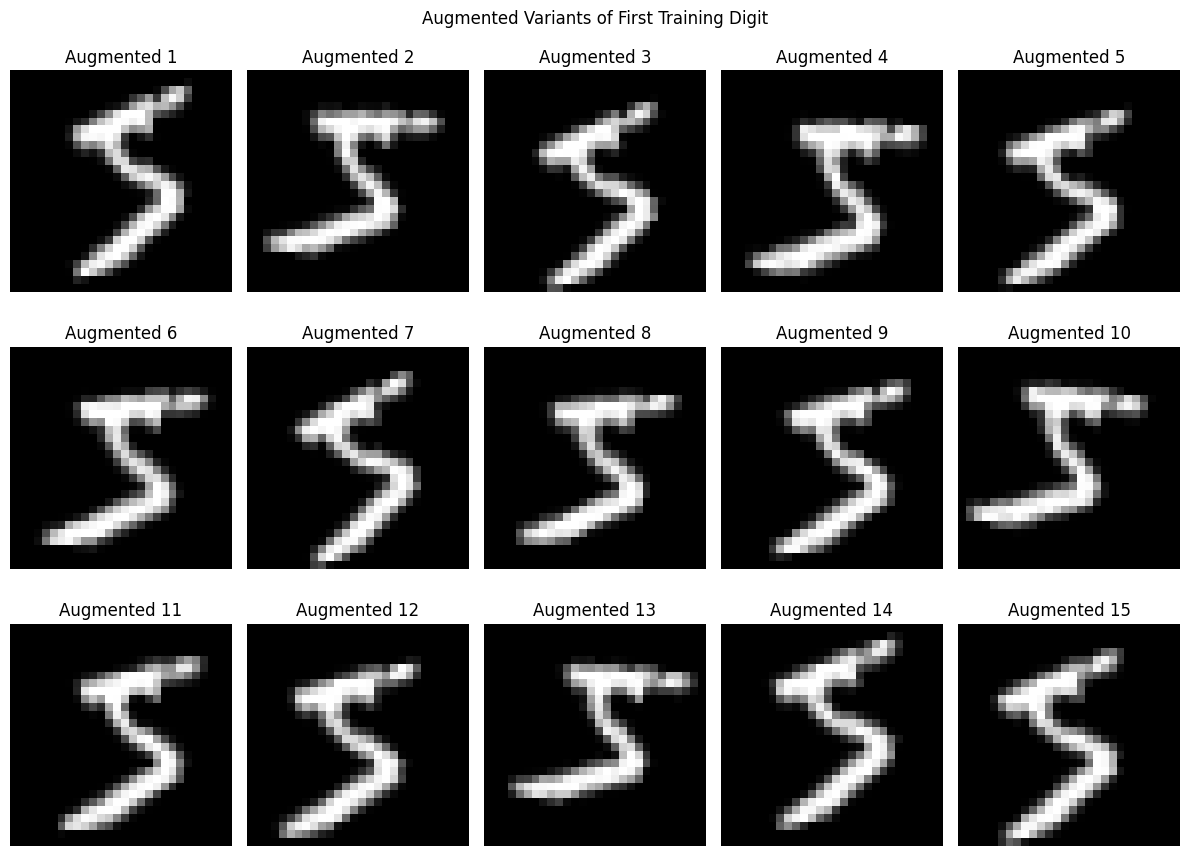

In [85]:
fig, axes = plt.subplots(3, 5, figsize=(12, 9))
sample_image = X_train[0].reshape(1, 28, 28, 1)

for row in range(3):
    for col in range(5):
        # Get augmented image from flow
        augmented_batch = next(augmentation.flow(sample_image, batch_size=1))
        augmented_image = augmented_batch[0].squeeze()  # Remove extra dimensions
        axes[row, col].imshow(augmented_image, cmap='gray')
        axes[row, col].set_title(f'Augmented {row*5 + col + 1}')
        axes[row, col].axis('off')

plt.suptitle(f'Augmented Variants of First Training Digit')
plt.tight_layout()
plt.show()

In [86]:
model_with_aug = create_model()
hist_aug = model_with_aug.fit(
    augmentation.flow(X_train, y_train, batch_size= 32),
    epochs = epochs_var,
    steps_per_epoch = len(X_train)//32,
    validation_data = (X_test, y_test),
    verbose = 1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.3130 - loss: 2.0511 - val_accuracy: 0.6478 - val_loss: 1.3104
Epoch 2/50
 1/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5625 - loss: 1.5380

/home/rithik/coding/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5625 - loss: 1.5380 - val_accuracy: 0.6862 - val_loss: 1.2682
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5764 - loss: 1.2676 - val_accuracy: 0.7918 - val_loss: 0.7095
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7812 - loss: 0.6612 - val_accuracy: 0.7966 - val_loss: 0.7009
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7169 - loss: 0.8752 - val_accuracy: 0.8644 - val_loss: 0.4741
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6875 - loss: 0.8815 - val_accuracy: 0.8702 - val_loss: 0.4665
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8068 - loss: 0.6662 - val_accuracy: 0.8872 - val_loss: 0.3635
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7500 - loss: 0.5915 - val_accuracy: 0.8872 - val_loss: 0.3609
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8409 - loss: 0.5399 - val_accuracy: 0.9038 - val_loss: 0.2

In [87]:
# Evaluate on test set
loss_with, acc_with = model_with_aug.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print("Model WITH Data Augmentation")
print("=" * 50)
print(f"Test Loss: {loss_with:.4f}")
print(f"Test Accuracy: {acc_with:.4f}")
print("=" * 50)

Model WITH Data Augmentation
Test Loss: 0.1519
Test Accuracy: 0.9502


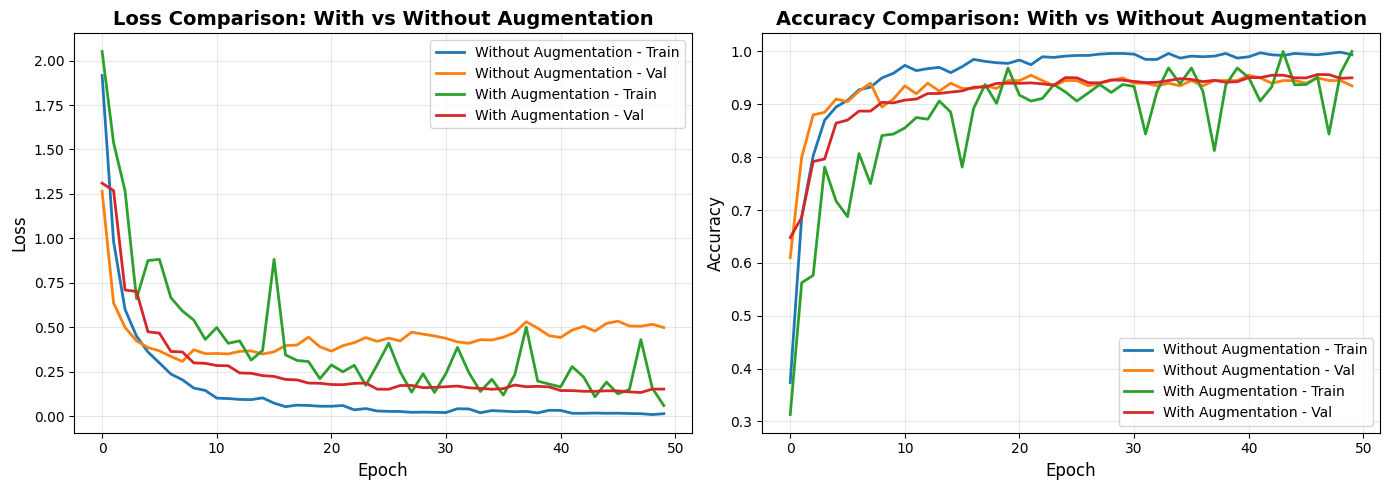


DATA AUGMENTATION COMPARISON SUMMARY

WITHOUT Augmentation:
  Final Train Loss: 0.0135
  Final Val Loss: 0.4984
  Test Accuracy: 0.9234

WITH Augmentation:
  Final Train Loss: 0.0593
  Final Val Loss: 0.1519
  Test Accuracy: 0.9502

Accuracy Difference: +0.0268


In [88]:
# Plot training history comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss comparison
axes[0].plot(hist1.history['loss'], label='Without Augmentation - Train', linewidth=2)
axes[0].plot(hist1.history['val_loss'], label='Without Augmentation - Val', linewidth=2)
axes[0].plot(hist_aug.history['loss'], label='With Augmentation - Train', linewidth=2)
axes[0].plot(hist_aug.history['val_loss'], label='With Augmentation - Val', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss Comparison: With vs Without Augmentation', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy comparison
axes[1].plot(hist1.history['accuracy'], label='Without Augmentation - Train', linewidth=2)
axes[1].plot(hist1.history['val_accuracy'], label='Without Augmentation - Val', linewidth=2)
axes[1].plot(hist_aug.history['accuracy'], label='With Augmentation - Train', linewidth=2)
axes[1].plot(hist_aug.history['val_accuracy'], label='With Augmentation - Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy Comparison: With vs Without Augmentation', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n" + "=" * 60)
print("DATA AUGMENTATION COMPARISON SUMMARY")
print("=" * 60)
print(f"\nWITHOUT Augmentation:")
print(f"  Final Train Loss: {hist1.history['loss'][-1]:.4f}")
print(f"  Final Val Loss: {hist1.history['val_loss'][-1]:.4f}")
print(f"  Test Accuracy: {acc_without:.4f}")

print(f"\nWITH Augmentation:")
print(f"  Final Train Loss: {hist_aug.history['loss'][-1]:.4f}")
print(f"  Final Val Loss: {hist_aug.history['val_loss'][-1]:.4f}")
print(f"  Test Accuracy: {acc_with:.4f}")

print(f"\nAccuracy Difference: {acc_with - acc_without:+.4f}")
print("=" * 60)

## 📚 Key Learnings from Today's Experiments

### Experiment 1: Data Augmentation Impact

#### Finding 1: Dataset Size Matters
- **Large datasets (60K+):** Augmentation HURTS performance
  - Model has enough real data, synthetic variations = noise
- **Small datasets (1K-10K):** Augmentation HELPS performance
  - Provides more training examples, reduces overfitting

#### Finding 2: Augmentation Strength is Critical
- **Too strong (0.1):** Causes instability, noisy learning curves ❌
- **Too weak (0.01):** Minimal benefit ❌
- **Goldilocks zone (0.05):** Best balance for 1K samples ✓

#### Finding 3: Overfitting Pattern
| Metric | Without Aug | With Aug | Difference |
|--------|------------|---------|-----------|
| Train Accuracy | 99% | 97% | -2% |
| Val Accuracy | 93% | 94% | +1% |
| Train/Val Gap | 6% | 3% | -3% ✓ |

- **Without augmentation:** Large train/val gap (99% vs 93%) → Model memorizes
- **With augmentation:** Smaller gap (97% vs 94%) → Better generalization

#### Finding 4: Real-World Impact
✓ Validation accuracy matters more than training accuracy  
✓ Augmentation prevents memorization  
✓ Better for real-world deployment where data varies  